In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def dataset():
    group = np.array([[1.0,1.1],[1.0,1.0],[0,0],[0,0.1]])
    labels = ['A','A','B','B']
    return group, labels

group,labels = dataset()
group, labels

(array([[1. , 1.1],
        [1. , 1. ],
        [0. , 0. ],
        [0. , 0.1]]),
 ['A', 'A', 'B', 'B'])

In [18]:
def classify0(x, dataset, labels, k):
    dis = np.sqrt(np.sum((x - dataset) ** 2, axis=1))
    sorted_indices=dis.argsort()
	
    class_count = {}
    for i in range(k):
	    label = labels[sorted_indices[i]]
	    class_count[label] = class_count.get(label, 0) + 1
		
    sorted_votes = sorted(class_count.items(), key=lambda x:x[1], reverse = True)
	
    return sorted_votes[0][0]

if __name__ == "__main__":
    pred=classify0([0,0],group,labels,3)
    print(f"The prediction result is: {pred}")


The prediction result is: B


In [20]:

def file2matrix(filename):
    data_list = []  # Initialize container for dynamic accumulation
    label_list = []
    
    with open(filename) as f:
        for line in f:
            line = line.strip()  # Remove leading and trailing whitespace
            if not line:         # Skip empty lines
                continue
            
            parts = line.split('\t')  # Split by tab delimiter
            # Each line contains 3 features and 1 label
            data_list.append(parts[:3])
            label_list.append(int(parts[-1]))
            
    # Convert list to NumPy array with float64 precision
    return_mat = np.array(data_list, dtype=np.float64)
    return return_mat, label_list


data_mat, labels = file2matrix("datingTestSet.txt")
print(data_mat[0:5])
print(labels[0:5])

[[4.0920000e+04 8.3269760e+00 9.5395200e-01]
 [1.4488000e+04 7.1534690e+00 1.6739040e+00]
 [2.6052000e+04 1.4418710e+00 8.0512400e-01]
 [7.5136000e+04 1.3147394e+01 4.2896400e-01]
 [3.8344000e+04 1.6697880e+00 1.3429600e-01]]
[3, 2, 1, 1, 1]


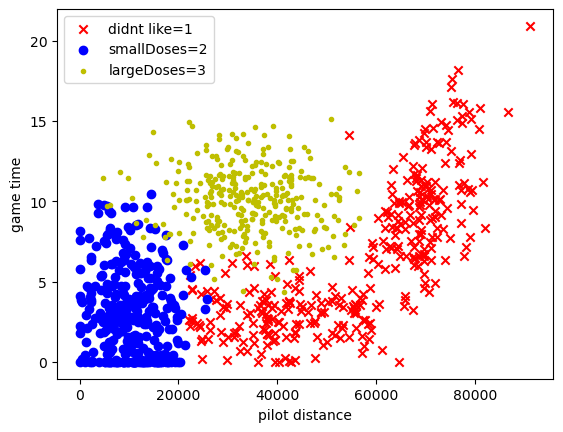

In [27]:

def plot(x,y):
    label1 = np.where(y == 1)[0]
    plt.scatter(x[label1,0],x[label1,1],marker='x',color = 'r',label = 'didnt like=1')
    label2 = np.where(y == 2)[0]
    plt.scatter(x[label2,0],x[label2,1],marker='o',color = 'b',label = 'smallDoses=2')
    label3 = np.where(y == 3)[0]
    plt.scatter(x[label3,0],x[label3,1],marker='.',color = 'y',label = 'largeDoses=3')
    plt.xlabel('pilot distance')
    plt.ylabel('game time')
    plt.legend(loc = 'upper left')
    plt.show()
    
plot(data_mat,np.array(labels).reshape(-1,1)) 

In [23]:
def autoNorm(dataset):
    min_vals = dataset.min(axis=0)
    max_vals = dataset.max(axis=0)
    norm_data = (dataset - min_vals) / (max_vals - min_vals)
    return norm_data, min_vals

In [25]:
def dating_class_test():
    """
    Test the kNN classifier on the dating dataset.
    """
    ho_ratio = 0.1  # Hold-out ratio for testing data
    
    # Load and normalize data
    dating_data_mat, dating_labels = file2matrix('datingTextSet.txt')
    norm_mat, ranges, min_vals = auto_norm(dating_data_mat)
    
    m = norm_mat.shape[0]
    num_test_vecs = int(m * ho_ratio)
    error_count = 0.0  # Initialize error counter
    
    for i in range(num_test_vecs):
        # The first num_test_vecs are used for testing, the rest for training
        classifier_result = classify0(
            norm_mat[i, :], 
            norm_mat[num_test_vecs:m, :], 
            dating_labels[num_test_vecs:m], 
            3
        )
        
        print(f"The classifier came back with: {classifier_result}, "
              f"the real answer is: {dating_labels[i]}")
        
        if classifier_result != dating_labels[i]:
            error_count += 1.0
            
    # Calculate and display the final error rate
    error_rate = error_count / float(num_test_vecs)
    print(f"\nThe total error rate is: {error_rate:.2%}")